In [1]:
# installing imblearn for SMOTE
!pip install imbalanced-learn


In [2]:
#importing pandas and sklearn
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [9]:
# Loading the credit card dataset downloaded from Kaggle

df = pd.read_csv("creditcard.csv")

# droping missing values
df = df.dropna()

# drop 'Time' column (not useful for prediction)
df = df.drop(columns=["Time"])

# 🎯 Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [15]:
# Addressing the data imbalance using SMOTE

# Feature scaling (important for SMOTE)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Applying SMOTE on training data to balance the classes
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Check the class distribution after SMOTE
print("Original class distribution:\n", y_train.value_counts())
print("Resampled class distribution:\n", pd.Series(y_train_resampled).value_counts())


Original class distribution:
 Class
0    227451
1       394
Name: count, dtype: int64
Resampled class distribution:
 Class
0    227451
1    227451
Name: count, dtype: int64


Logistic Regression Metrics:
Accuracy: 0.9741055440469084
Precision: 0.057803468208092484
Recall: 0.9183673469387755
F1 Score: 0.10876132930513595
ROC AUC: 0.9708434302252134
Confusion Matrix:
 [[55397  1467]
 [    8    90]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



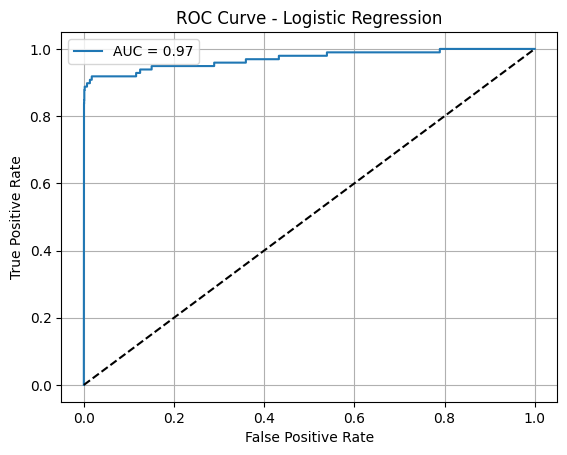

In [5]:
# Building and evaluating a Logistic Regression model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# training a Logistic Regression model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_resampled, y_train_resampled)
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation Metrics
print("Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

# Plotting ROC Curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
plt.figure()
plt.plot(fpr_log, tpr_log, label=f"AUC = {roc_auc_score(y_test, y_prob_log):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

Decision Tree Metrics:
Accuracy: 0.997559776693234
Precision: 0.39487179487179486
Recall: 0.7857142857142857
F1 Score: 0.5255972696245734
ROC AUC: 0.8918195795481951
Confusion Matrix:
 [[56746   118]
 [   21    77]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.39      0.79      0.53        98

    accuracy                           1.00     56962
   macro avg       0.70      0.89      0.76     56962
weighted avg       1.00      1.00      1.00     56962



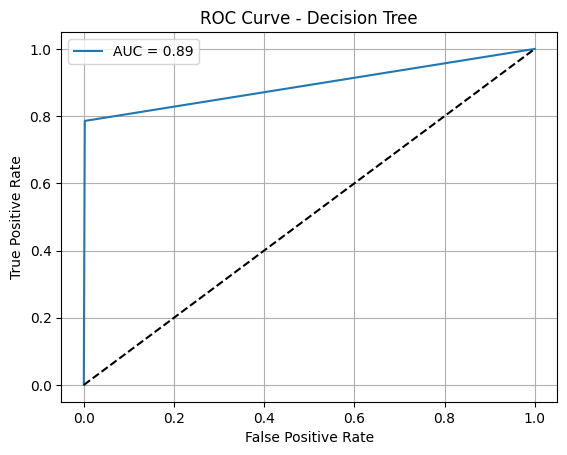

In [6]:
# Building and evaluating a Decision Tree model

from sklearn.tree import DecisionTreeClassifier

# training Decision Tree model

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)
y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation Metrics

print("Decision Tree Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC AUC:", roc_auc_score(y_test, y_prob_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# ROC Curve for Decision Tree model
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
plt.figure()
plt.plot(fpr_dt, tpr_dt, label=f"AUC = {roc_auc_score(y_test, y_prob_dt):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Decision Tree")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

Random Forest Metrics:
Accuracy: 0.999420666409185
Precision: 0.8494623655913979
Recall: 0.8061224489795918
F1 Score: 0.8272251308900523
ROC AUC: 0.9729411671815603
Confusion Matrix:
 [[56850    14]
 [   19    79]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.81      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



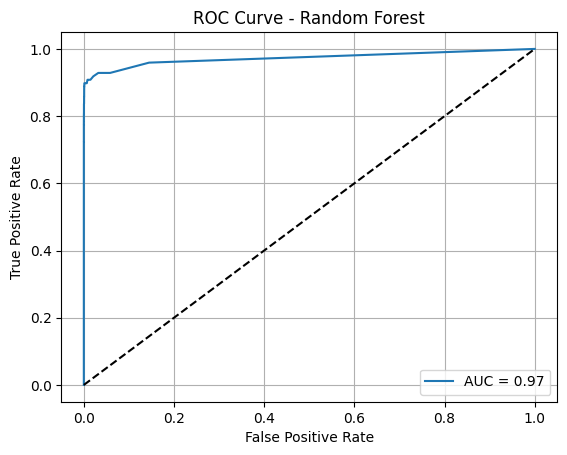

In [16]:
# Building and evaluating a Random Forest model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Training Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation Metrics
print("Random Forest Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# ROC Curve for Random Forest Model
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {roc_auc_score(y_test, y_prob_rf):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

In [17]:
# Findings
# Logistic Regression has high recall but terrible precision wit tons of false positives.

# Decision Tree is much better and more balanced with a decent precision and recall.

# Random Forest is clearly the best performer offering both high precision and high recall, which leads to a very strong F1 score (0.85). This is ideal for fraud detection.

In [18]:
# Saving the RF model

import joblib

# Save the model
joblib.dump(rf_model, "random_forest_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']